# 03 DFA Analysis

Goal:

Use residuals from notebook 02 and analyze their scaling dynamics with detrended fluctuation analysis.

Workflow:

- load `residuals.csv`
- join the model winner per player from `model_comparison.csv`
- group residuals by player
- run DFA
- compute the Hurst exponent
- classify noise type
- save `dfa_results.csv`
- produce residual series plots
- produce DFA scaling plots

Outputs:

- `dfa_results.csv`
- `figures/dfa_residual_series/*.png`
- `figures/dfa_scaling/*.png`

In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "data" / "processed").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data_loading import processed_data_dir, results_data_dir
from src.dfa_analysis import calculate_hurst_exponent, classify_noise
from src.visualization import plot_dfa_scaling, plot_residual_series

experiment_name = "case_study_333_10players"
processed_dir = processed_data_dir(ROOT, experiment_name=experiment_name)
results_dir = results_data_dir(ROOT, experiment_name=experiment_name)
figures_dir = results_dir / "figures"
residual_series_dir = figures_dir / "dfa_residual_series"
scaling_dir = figures_dir / "dfa_scaling"

results_dir.mkdir(parents=True, exist_ok=True)
residual_series_dir.mkdir(parents=True, exist_ok=True)
scaling_dir.mkdir(parents=True, exist_ok=True)

residuals_path = results_dir / "residuals.csv"
model_comparison_path = results_dir / "model_comparison.csv"
dfa_results_path = results_dir / "dfa_results.csv"

print(f"Residual input path: {residuals_path}")
print(f"Model comparison path: {model_comparison_path}")
print(f"Results dir: {results_dir}")

if not residuals_path.exists():
    raise FileNotFoundError(f"Residuals file not found: {residuals_path}")
if not model_comparison_path.exists():
    raise FileNotFoundError(f"Model comparison file not found: {model_comparison_path}")

residuals_df = pd.read_csv(residuals_path, parse_dates=["competition_date"])
model_comparison = pd.read_csv(model_comparison_path)

model_choice = model_comparison[["person_id", "person_name", "winner", "winner_bic"]].copy()
model_choice["analysis_model"] = np.where(
    model_choice["winner"] == "tie",
    model_choice["winner_bic"],
    model_choice["winner"],
)

selected_residuals = residuals_df.merge(
    model_choice[["person_id", "analysis_model"]],
    on="person_id",
    how="inner",
)
selected_residuals = selected_residuals.loc[
    selected_residuals["model"] == selected_residuals["analysis_model"]
].copy()
selected_residuals = selected_residuals.sort_values(["person_id", "seq_index"]).reset_index(drop=True)

print(f"Residual rows loaded: {len(residuals_df)}")
print(f"Players selected for DFA: {selected_residuals['person_id'].nunique()}")
display(selected_residuals.head())

Residual input path: d:\OneDrive - TU Wien\Interdisciplinary Project\InterdisciplinaryProject_DynamicsOfMastery\data\results\residuals.csv
Model comparison path: d:\OneDrive - TU Wien\Interdisciplinary Project\InterdisciplinaryProject_DynamicsOfMastery\data\results\model_comparison.csv
Residual rows loaded: 14112
Players selected for DFA: 10


,person_id,person_name,model,seq_index,competition_date,observed_seconds,predicted_seconds,residual_seconds,analysis_model
0,2009LIUE01,Evan Liu,power_law,1,2009-05-30,44.77,40.999655,3.770345,power_law
1,2009LIUE01,Evan Liu,power_law,2,2009-08-14,33.30,31.529981,1.770019,power_law
2,2009LIUE01,Evan Liu,power_law,3,2010-01-30,20.28,27.291897,-7.011897,power_law
3,2009LIUE01,Evan Liu,power_law,4,2010-01-30,21.71,24.749461,-3.039461,power_law
4,2009LIUE01,Evan Liu,power_law,5,2010-04-18,20.91,23.006344,-2.096344,power_law


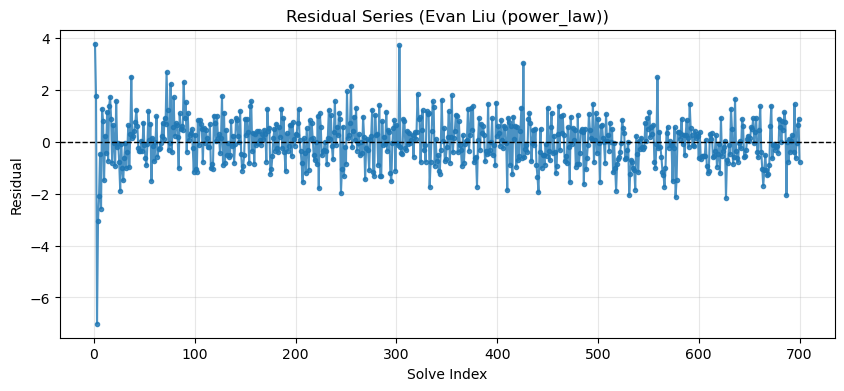

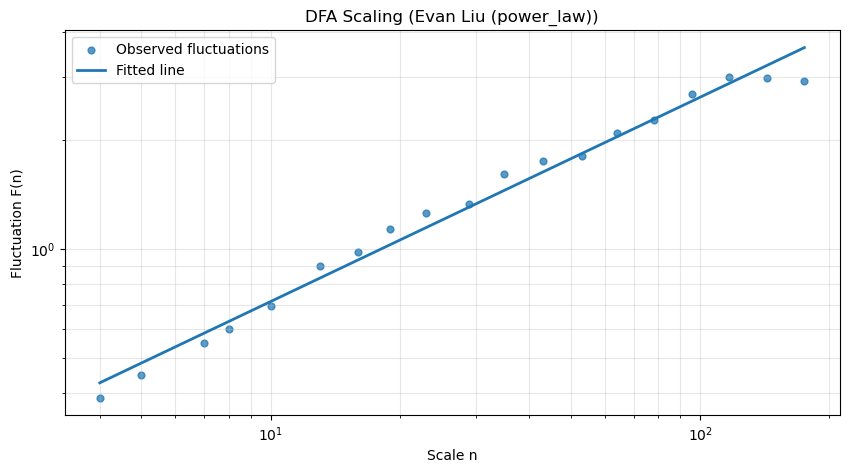

Saved DFA results to: d:\OneDrive - TU Wien\Interdisciplinary Project\InterdisciplinaryProject_DynamicsOfMastery\data\results\dfa_results.csv
Players analyzed: 10
DFA results:


,person_id,person_name,model,analysis_model,n_obs,hurst,intercept,dfa_r2,noise_type
0,2012PARK03,Max Park,power_law,power_law,617,0.904503,-3.092542,0.978295,persistent
1,2011EDUA01,Eduard Esteban García Domínguez,power_law,power_law,860,0.748138,-1.812402,0.953242,persistent
2,2014ZAKR01,Karol Zakrzewski,power_law,power_law,648,0.677807,-2.215673,0.988874,persistent
3,2010ROSE03,Dennis Rosero,power_law,power_law,759,0.655715,-1.780547,0.991307,persistent
4,2013WALL03,Daniel Wallin,power_law,power_law,711,0.652072,-2.098261,0.978457,persistent
5,2013ROGA02,Przemysław Rogalski,power_law,power_law,626,0.650527,-1.993415,0.987365,persistent
6,2012MAHV01,Paul Mahvi,power_law,power_law,701,0.650136,-2.091802,0.985245,persistent
7,2009PROV01,Matteo Provasi,power_law,power_law,750,0.638867,-1.904636,0.988472,persistent
8,2010HULL01,Katie Hull,power_law,power_law,684,0.596998,-2.003561,0.993440,persistent
9,2009LIUE01,Evan Liu,power_law,power_law,700,0.565630,-1.636498,0.984390,persistent



Average Hurst exponent:
0.674039272890538

Average DFA R²:
0.9829086888245031
Noise type counts:


,noise_type,count
0,persistent,10


Hurst and DFA fit summary:


,hurst,dfa_r2
count,10.000000,10.000000
mean,0.674039,0.982909
std,0.093978,0.011531
min,0.565630,0.953242
25%,0.641684,0.979940
50%,0.651300,0.986305
75%,0.672284,0.988774
max,0.904503,0.993440


In [ ]:
def analyze_player_dfa(group):
    """Run DFA for one player's residual series."""

    group = group.sort_values("seq_index").reset_index(drop=True)
    signal = group["residual_seconds"].to_numpy(dtype=float)
    result = calculate_hurst_exponent(signal)

    return {
        "person_id": group["person_id"].iloc[0],
        "person_name": group["person_name"].iloc[0],
        "model": group["model"].iloc[0],
        "analysis_model": group["analysis_model"].iloc[0],
        "n_obs": int(len(group)),
        "hurst": result["hurst"],
        "intercept": result["intercept"],
        "dfa_r2": result["dfa_r2"],
        "noise_type": classify_noise(result["hurst"]),
    }, result


dfa_rows = []
failed_players = []

for index, (_, group) in enumerate(selected_residuals.groupby("person_id", sort=False)):
    try:
        summary, dfa_result = analyze_player_dfa(group)
    except Exception as e:
        failed_players.append(
            {
                "person_id": group["person_id"].iloc[0],
                "error": str(e),
            }
        )
        continue

    dfa_rows.append(summary)

    person_id = summary["person_id"]
    person_name = summary["person_name"]
    model_name = summary["model"]
    analysis_model = summary["analysis_model"]

    residual_plot_path = residual_series_dir / f"{person_id}_{analysis_model}_residual_series.png"
    scaling_plot_path = scaling_dir / f"{person_id}_{analysis_model}_dfa_scaling.png"

    fig, ax = plot_residual_series(
        group["seq_index"].to_numpy(dtype=float),
        group["residual_seconds"].to_numpy(dtype=float),
        player_id=f"{person_name} ({model_name})",
    )
    fig.savefig(residual_plot_path, dpi=200, bbox_inches="tight")
    if index == 0:
        display(fig)
    plt.close(fig)

    fig, ax = plot_dfa_scaling(
        dfa_result["scales"],
        dfa_result["fluctuations"],
        slope=dfa_result["hurst"],
        intercept=dfa_result["intercept"],
        player_id=f"{person_name} ({model_name})",
    )
    fig.savefig(scaling_plot_path, dpi=200, bbox_inches="tight")
    if index == 0:
        display(fig)
    plt.close(fig)


dfa_results = pd.DataFrame(dfa_rows)
if not dfa_results.empty:
    dfa_results = dfa_results.sort_values(["hurst", "dfa_r2"], ascending=[False, False]).reset_index(drop=True)

dfa_results.to_csv(dfa_results_path, index=False)

print(f"Saved DFA results to: {dfa_results_path}")
print(f"Players analyzed: {len(dfa_results)}")
print("DFA results:")
display(dfa_results)

print("\nAverage Hurst exponent:")
print(dfa_results["hurst"].mean())

print("\nAverage DFA R²:")
print(dfa_results["dfa_r2"].mean())

print("Noise type counts:")
if not dfa_results.empty:
    display(dfa_results["noise_type"].value_counts().rename_axis("noise_type").reset_index(name="count"))
else:
    print("No valid DFA results.")

print("Hurst and DFA fit summary:")
if not dfa_results.empty:
    display(dfa_results[["hurst", "dfa_r2"]].describe())

if failed_players:
    print("Failed players:")
    display(pd.DataFrame(failed_players))

## DFA and Hurst Estimation

For each player, use the winning model residual series, estimate DFA scaling, and save a compact summary for the report.